In [1]:
import numpy as np
from importlib import reload
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import pandas as pd
from tqdm import tqdm

import sys
sys.path.append('../')

import proba_modules as pm
import VCD_trajectory_modules as VCD
import proba_volcanoes_modules as pvm

## Loading TL curves

In [2]:
from scipy import interpolate
dir_data = '../data/'
file_atmos = f'{dir_data}profile_VCD_for_scaling_pd.csv'
profile = pd.read_csv(file_atmos)
f_rho = interpolate.interp1d(profile.altitude/1e3, profile.rho, kind='quadratic')
f_t = interpolate.interp1d(profile.altitude/1e3, profile.t, kind='quadratic')
f_gamma = interpolate.interp1d(profile.altitude/1e3, profile.gamma, kind='quadratic')
f_c = interpolate.interp1d(profile.altitude/1e3, profile.c, kind='quadratic')

In [3]:
reload(pm)

dir_GF = '../data/' ## TO CHANGE
file_curve = f'{dir_GF}GF_Dirac_1Hz_combined_wHot40.csv'
alt_balloon = 50.
opt_TL = dict(
    rho0=f_rho(0.), 
    rhob=f_rho(alt_balloon), 
    cb=f_c(alt_balloon), 
    unknown='pressure', 
    model='Cold100'
)
TL_new, TL_new_qmin, TL_new_qmax = pm.get_TL_curves_precomputed(file_curve, **opt_TL)

## Loading seismo-volcanic catalog

In [4]:
catalog_hawai = pd.read_csv(f'{dir_data}hawai_catalog_since_1983.csv', header=[0])
catalog_hawai.loc[:,'UTC'] = pd.to_datetime(catalog_hawai.UTC)
catalog_hawai = catalog_hawai.loc[catalog_hawai.mag>=3.]

all_mags = catalog_hawai.mag.values
all_times = catalog_hawai['time (years)'].values

/tmp/ipykernel_1679806/671262490.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '<DatetimeArray>
['1983-01-02 19:48:51.300000', '1983-01-03 03:00:10.640000',
 '1983-01-03 05:39:52.500000',        '1983-01-03 21:55:04',
 '1983-01-05 14:54:13.020000', '1983-01-16 17:33:53.640000',
 '1983-01-23 20:13:39.840000', '1983-01-23 20:46:46.620000',
 '1983-01-24 04:00:24.890000', '1983-01-25 09:08:28.240000',
 ...
 '2024-08-20 12:21:53.340000', '2024-08-20 12:46:17.780000',
 '2024-08-20 13:33:31.590000', '2024-08-20 13:52:10.390000',
 '2024-08-20 19:22:25.890000', '2024-08-21 07:28:42.660000',
 '2024-08-22 05:17:55.800000', '2024-08-22 10:52:44.890000',
 '2024-08-23 09:03:39.560000', '2024-08-29 06:22:50.350000']
Length: 4101, dtype: datetime64[ns]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  catalog_hawai.loc[:,'UTC'] = pd.to_datetime(catalog_hawai.UTC)


/staff/quentin/Documents/Projects/2024_Venus_Detectability/Venus_Detectability/proba_volcanoes_modules.py:293: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax_zoom.scatter(catalog_loc.UTC, catalog_loc.mag, c='tab:green', alpha=0.3, cmap='Greens', s=3)


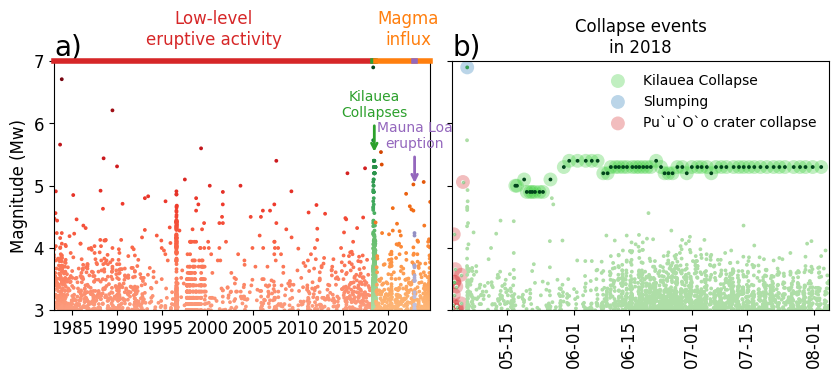

In [7]:
reload(pvm)

fig = plt.figure(figsize=(10,5))
grid = fig.add_gridspec(3, 6)

ax_first = fig.add_subplot(grid[:2,:3])
ax_zoom = fig.add_subplot(grid[:2,3:], sharey=ax_first)

pvm.plot_sequence_events(fig, ax_first, ax_zoom, catalog_hawai, max_val=7., fontsize=12., fontsize_label=20.)

## Load atmospheric model

In [5]:
reload(VCD)

file_atmos = f'{dir_data}VCD_atmos_globe_new.dat'
winds = VCD.get_winds(file_atmos, alt_balloon*1e3)

/staff/quentin/Documents/Projects/2024_Venus_Detectability/Venus_Detectability/notebooks/../VCD_trajectory_modules.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  winds['gid'] = winds.groupby(['lat', 'lon'])['val'].transform('idxmin')
/staff/quentin/Documents/Projects/2024_Venus_Detectability/Venus_Detectability/notebooks/../VCD_trajectory_modules.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  winds['wind_strength'] = winds.groupby(['lat', 'lon'])['val'].transform(lambda x: np.sqrt(sum(x**2)))
/s

In [9]:
reload(VCD)
wind_direction_interpolator, wind_strength_interpolator, _ = VCD.get_winds_interpolator(file_atmos, alt_balloon*1e3, winds=winds)

## Parameter space for flights

### High spatial and trajectory time without drop off time

In [10]:
R0 = 6371000  # Earth's radius in meters
#lat_vol, lon_vol = -32.5, 132.1
lat_vol, lon_vol = 8.687137, -52.476376
lat_offset, lon_offset = np.linspace(-50., 50., 8), np.linspace(-50., 50., 4)
t0s_offset = np.arange(all_times.min()-2./12, all_times.max()-2./12, 6/12) # in years
#vlat = -0.4  # Latitude velocity in meters per second
#vlon = -50/110.  # Longitude velocity in meters per second
mission_duration = (6./12.)*365*24*3600
arrival_time = lambda dist, h_balloon, t0: t0 + (h_balloon/0.35 + dist/3.5)

LAT_offset, LON_offset = np.meshgrid(lat_offset, lon_offset)
LAT_offset_shape_init = LAT_offset.shape
LAT_offset, LON_offset = LAT_offset.ravel(), LON_offset.ravel()
lat0 = lat_vol+LAT_offset  # Initial latitude in degrees
lon0 = lon_vol+LON_offset  # Initial longitude in degrees

dt = 1*3600/6.
times = np.arange(0, mission_duration, dt) 
TIMES, ID_LAT0 = np.meshgrid(times, np.arange(LAT_offset.size))
shape_TIMES = TIMES.shape # balloon init loc/t0 x balloon flight time 
TIMES, ID_LAT0 = TIMES.ravel(), ID_LAT0.ravel() 

In [11]:
reload(pvm)

dt_new = mission_duration/100.
idx_dt_step = int(dt_new/dt)
times_downsampled = times[::idx_dt_step]
latitudes, longitudes = pvm.compute_positions_vectorized_w_interpolator(lat0[ID_LAT0].reshape(shape_TIMES), lon0[ID_LAT0].reshape(shape_TIMES), wind_direction_interpolator, wind_strength_interpolator, TIMES.reshape(shape_TIMES), R0)
#latitudes, longitudes = compute_positions_vectorized(lat0[ID_LAT0].reshape(shape_TIMES), lon0[ID_LAT0].reshape(shape_TIMES), vlat_func, vlon, TIMES.reshape(shape_TIMES), R0)
#longitudes[longitudes<0] += 360.
latitudes, longitudes = latitudes.reshape(shape_TIMES)[:,::idx_dt_step], longitudes.reshape(shape_TIMES)[:,::idx_dt_step]

  6%|▌         | 1570/26279 [00:00<00:01, 15690.33it/s]

100%|██████████| 26279/26279 [00:01<00:00, 15616.08it/s]


In [12]:
distances = pvm.haversine_distance(latitudes, longitudes, lat_vol, lon_vol, R0)

### Low resolution trajectory time with drop off time

In [13]:
R0 = 6371000  # Earth's radius in meters
#lat_vol, lon_vol = -32.5, 132.1
lat_vol, lon_vol = 8.687137, -52.476376
lat_offset, lon_offset = np.linspace(-50., 50., 8), np.linspace(-50., 50., 4)
t0s_offset = np.arange(all_times.min()-2./12, all_times.max()-2./12, 6/12) # in years
#vlat = -0.4  # Latitude velocity in meters per second
#vlon = -50/110.  # Longitude velocity in meters per second
mission_duration = (6./12.)*365*24*3600
arrival_time = lambda dist, h_balloon, t0: t0 + (h_balloon/0.35 + dist/3.5)

LAT_offset, LON_offset, T0s_offset = np.meshgrid(lat_offset, lon_offset, t0s_offset)
LAT_offset_shape = LAT_offset.shape
LAT_offset, LON_offset, T0s_offset = LAT_offset.ravel(), LON_offset.ravel(), T0s_offset.ravel()
lat0 = lat_vol+LAT_offset  # Initial latitude in degrees
lon0 = lon_vol+LON_offset  # Initial longitude in degrees

#dt = 1*3600/6.
#times = np.arange(0, mission_duration, dt_new) 
TIMES, ID_LAT0 = np.meshgrid(times_downsampled, np.arange(LAT_offset.size))
shape_TIMES = TIMES.shape # balloon init loc/t0 x balloon flight time 
TIMES, ID_LAT0 = TIMES.ravel(), ID_LAT0.ravel() 

In [14]:
latitudes, longitudes = None, None

In [15]:
distances[:,0].reshape(LAT_offset_shape_init)[:,:,None].shape, distances.shape

((4, 8, 1), (32, 101))

### Convert back to appropriate dimension that includes drop off time

In [16]:
distances_repeated = np.zeros(shape_TIMES)
for itime in tqdm(range(shape_TIMES[-1])):
    distances_repeated[:,itime] = np.repeat(distances[:,0].reshape(LAT_offset_shape_init)[:,:,None], t0s_offset.size, axis=-1).ravel()
distances = None

100%|██████████| 101/101 [00:00<00:00, 28890.73it/s]


In [17]:
distances_repeated = distances_repeated.ravel()

## Compute SNR at each balloon location

In [18]:
reload(pvm)

batch_size = 100
freq = 0.1
mags_ev, amps_ev, mask = pvm.get_amps_at_baloons(T0s_offset, LAT_offset, ID_LAT0, TIMES, times_downsampled, shape_TIMES, all_times, all_mags, distances_repeated, TL_new[freq], arrival_time, batch_size)

100%|██████████| 27/27 [00:54<00:00,  2.04s/it]


In [ ]:
file = f'../data/volcanoes/mags_ev_{1./freq:.0f}s_1983_fixed.npy'
with open(file, 'wb') as f:
    np.save(f, mags_ev)

In [ ]:
file = f'../data/volcanoes/amps_ev_{1./freq:.0f}s_1983_fixed.npy'
with open(file, 'wb') as f:
    np.save(f, amps_ev)

In [ ]:
file = f'../data/volcanoes/mask_{1./freq:.0f}s_1983_fixed.npy'
with open(file, 'wb') as f:
    np.save(f, mask)

## Visualization

### Small

In [19]:
#snr_threshold=1
#number_over_snr = ((amps_ev*(mask)/noise_level)>snr_threshold).sum(axis=0).reshape(LAT_offset_shape)
noise_level=1e-2
snr_threshold=1
idamp = (amps_ev*(mask)).argmax(axis=0)[None,:]  
amps_ev_reshaped = np.take_along_axis(amps_ev*(mask) + 1e-10*(~mask), idamp, axis=0)[0].reshape(LAT_offset_shape) # lon x lat x t0

In [20]:
snrs = np.logspace(np.log10(0.1),np.log10(10.), 50)
number_over_snr = np.zeros((snrs.size,) + LAT_offset_shape)
for isnr,  snr in tqdm(enumerate(snrs), total=snrs.size):
    number_over_snr[isnr,:] = ((amps_ev*(mask)/noise_level)>snr).sum(axis=0).reshape(LAT_offset_shape)

100%|██████████| 50/50 [00:02<00:00, 18.06it/s]


/staff/quentin/Documents/Projects/2024_Venus_Detectability/Venus_Detectability/proba_volcanoes_modules.py:293: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax_zoom.scatter(catalog_loc.UTC, catalog_loc.mag, c='tab:green', alpha=0.3, cmap='Greens', s=3)


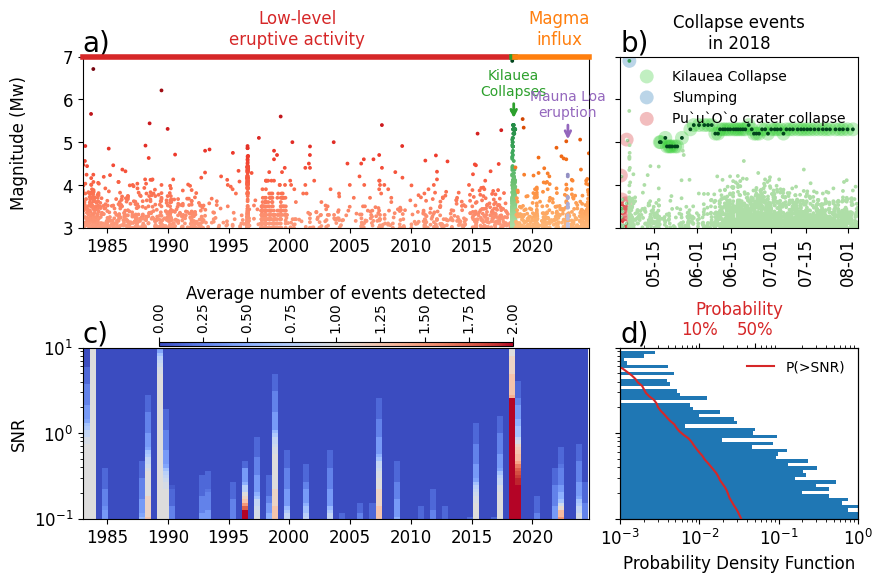

In [21]:
reload(pvm)

fig = pvm.plot_proba_sequence_small(catalog_hawai, amps_ev, t0s_offset, LAT_offset_shape, mask, snrs, noise_level = 0.01, fontsize=12., number_over_snr=number_over_snr, idamp=idamp, amps_ev_reshaped=amps_ev_reshaped, color_labels='black', fontsize_label=20.)

In [ ]:
fig.savefig('../figures/Figure_4_volcanoes_small_1983_10s_fixed.pdf')

### Large

In [ ]:
#snr_threshold=1
#number_over_snr = ((amps_ev*(mask)/noise_level)>snr_threshold).sum(axis=0).reshape(LAT_offset_shape)
noise_level=1e-2
snr_threshold=1
idamp = (amps_ev*(mask)).argmax(axis=0)[None,:]  
amps_ev_reshaped = np.take_along_axis(amps_ev*(mask) + 1e-10*(~mask), idamp, axis=0)[0].reshape(LAT_offset_shape) # lon x lat x t0

In [ ]:
#number_over_snr = ((amps_ev*(mask)/noise_level)>snr_threshold).sum(axis=0).reshape(LAT_offset_shape)
snrs = np.logspace(np.log10(0.1),np.log10(10.), 50)
number_over_snr = np.zeros((snrs.size,) + LAT_offset_shape)
for isnr,  snr in tqdm(enumerate(snrs), total=snrs.size):
    number_over_snr[isnr,:] = ((amps_ev*(mask)/noise_level)>snr).sum(axis=0).reshape(LAT_offset_shape)

In [ ]:
import datetime
interval = datetime.timedelta(days=30*6)

plt.figure()
ax = plt.gca()
datetimes = [catalog_hawai.UTC.min() + pd.Timedelta(days=year * 365.25) for year in t0s_offset]
ax.bar(datetimes, np.mean(number_over_snr, axis=(0,1)), log=True, color='tab:green', width=interval, label='Number of events per flight')
ax.axhline(1., linestyle='--', color='black')
ax.xaxis_date()
ax.set_ylim([1e-2, 6])
#ax.set_ylabel('Number of events per flight')
ax.legend(frameon=False)

bbox_to_anchor=(0., -0.26, 1, 1.)
axins = inset_axes(ax, width="100%", height="25%", loc='lower left', bbox_to_anchor=bbox_to_anchor, bbox_transform=ax.transAxes, borderpad=0)

In [ ]:
reload(pvm)

fig = pvm.plot_proba_sequence(catalog_hawai, amps_ev, all_times, all_mags, TL_new, lat_vol, t0s_offset, lat_offset, LAT_offset_shape, mask, noise_level=1e-2, factor = (np.log10(2.)+4.)/4., snr_threshold=1, number_over_snr=number_over_snr, amps_ev_reshaped=amps_ev_reshaped, color_labels='white')

In [ ]:
fig.tight_layout()
fig.savefig('./figures/Figure_4_volcanoes_AGU.png', transparent=True)